# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [73]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style="darkgrid")

## 1. LOAD DATA

In [74]:
# =========================
# ======= DATA LOAD =======
# =========================


TRAIN_PATH = "data/vertx_eth2dump-clean-combined.csv"
# TEST_PATH  = "data/vertx_realtime_normaltraffic_20260203.csv"
TEST_PATH  = "data/vertx_eth2dump-mitm-change-30m-6h_1.pcap.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"✅ Train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"✅ Test:  {test.shape[0]} rows × {test.shape[1]} columns")

✅ Train: 14570 rows × 59 columns
✅ Test:  27108 rows × 59 columns


In [75]:
# Aperçu des données
print("\n📊 Premières lignes du dataset d'entraînement:")
train.head()


📊 Premières lignes du dataset d'entraînement:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg
0,c4283545-663b-48e7-99b8-bff09dd0a286,172.27.224.250_172.27.224.70_502_49205_TCP,2018-09-08 19:06:12.784000000,2018-09-08 19:11:12.681000000,172.27.224.70,172.27.224.250,49205.0,502.0,TCP,202771,2883,{'P_172.27.224.70_172.27.224.250_TCP_ACK_15364...,"{20732,20732,20732,20732,20732,20732,20732,207...",299897,Max Age Exceeded,60,85,70.333336,10.658093,676.13550,9.613300,121086.0,81685.0,1922.0,961.0,1.482353,2.000,299897.0,104.058640,81.998130,1.0,224.0,0.674603,0.00,0.00,0.00,1.00,0.666667,0,0,0,2883,1922,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,133153048768736,NaN,NaN,NaN,NaN,NaN,NaN
1,f80c570d-b180-4f71-a5e1-c595fe681a6c,172.27.224.250_172.27.224.251_502_60106_TCP,2018-09-08 19:10:11.889000000,2018-09-08 19:10:13.359000000,172.27.224.251,172.27.224.250,60106.0,502.0,TCP,1506,25,{'P_172.27.224.251_172.27.224.250_TCP_SYN_1536...,"{21140,21141,21142,21143,21144,21146,21147,211...",1470,Inactivity Timeout,60,66,60.240000,1.200000,1024.48970,17.006804,1020.0,486.0,17.0,8.0,2.098765,2.125,1470.0,61.250000,249.369500,0.0,1216.0,0.476471,0.08,0.08,0.08,0.92,0.520000,2,2,2,23,13,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,133154119620352,NaN,NaN,NaN,NaN,NaN,NaN
2,0d0c0e23-525c-493b-98a1-99d9bec53007,172.27.224.250_172.27.224.70_502_49205_TCP,2018-09-08 19:11:12.891000000,2018-09-08 19:16:12.756000000,172.27.224.70,172.27.224.250,49205.0,502.0,TCP,202771,2883,{'P_172.27.224.70_172.27.224.250_TCP_ACK_15364...,"{21455,21455,21455,21454,21454,21454,21453,214...",299865,Max Age Exceeded,60,85,70.333336,10.658093,676.20764,9.614327,121086.0,81685.0,1922.0,961.0,1.482353,2.000,299865.0,104.047540,81.949690,2.0,223.0,0.674603,0.00,0.00,0.00,1.00,0.666667,0,0,0,2883,1922,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,133154122624816,NaN,NaN,NaN,NaN,NaN,NaN
3,f166bb82-5a54-404d-b5b1-f11eb0e347bb,172.27.224.250_172.27.224.70_502_49205_TCP,2018-09-08 19:16:12.968000000,2018-09-08 19:21:12.799000000,172.27.224.70,172.27.224.250,49205.0,502.0,TCP,202771,2883,{'P_172.27.224.70_172.27.224.250_TCP_ACK_15364...,"{21985,21985,21985,21985,21985,21985,21985,219...",299831,Max Age Exceeded,60,85,70.333336,10.658093,676.28430,9.615417,121086.0,81685.0,1922.0,961.0,1.482353,2.000,299831.0,104.035736,81.964584,1.0,224.0,0.674603,0.00,0.00,0.00,1.00,0.666667,0,0,0,2883,1922,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,133154122626112,NaN,NaN,NaN,NaN,NaN,NaN
4,df11018b-c9da-4ef6-b84a-ab867be14280,172.27.224.250_172.27.224.251_502_60322_TCP,2018-09-08 19:20:37.747000000,2018-09-08 19:20:39.217000000,172.27.224.251,172.27.224.250,60322.0,502.0,TCP,1506,25,{'P_172.27.224.251_172.27.224.250_TCP_SYN_1536...,"{22465,22467,22468,22469,22471,22473,22474,224...",1470,Inactivity Timeout,60,66,60.240000,1.200000,1024.48970,17.006804,1020.0,486.0,17.0,8.0,2.098765,2.125,1470.0,61.250000,249.543980,0.0,1217.0,0.476471,0.08,0.08,0.08,0.92,0.520000,2,2,2,23,13,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,133154122627408,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
# Informations sur les colonnes
print("\n📋 Informations sur les colonnes:")
train.info()


📋 Informations sur les colonnes:
<class 'pandas.DataFrame'>
RangeIndex: 14570 entries, 0 to 14569
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      14570 non-null  str    
 1   flowKey                 14570 non-null  str    
 2   firstSeen               14570 non-null  str    
 3   lastSeen                14570 non-null  str    
 4   srcIp                   14570 non-null  str    
 5   dstIp                   14570 non-null  str    
 6   srcPort                 12809 non-null  float64
 7   dstPort                 12809 non-null  float64
 8   protocol                14570 non-null  str    
 9   bytes                   14570 non-null  int64  
 10  packets                 14570 non-null  int64  
 11  packetSummaries         14570 non-null  str    
 12  treatmentDelay          14570 non-null  str    
 13  durationMs              14570 non-null  int64  
 14  reasonOfFlowEnd

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [77]:
# =========================
# ======= FEATURES =======
# =========================
BASE_FEATURES = [
    'bytes', 'packets', 'minPacketLength', 'maxPacketLength',
    'meanPacketLength', 'stddevPacketLength', 'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream',
    'totalPacketsDownstream', 'ratioBytesUpDown', 'ratioPacketsUpDown',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'interArrivalTimeMin', 'interArrivalTimeMax', 'flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg', "durationMs",'ratioBytesUpDown', 'ratioPacketsUpDown','flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

ALL_FEATURES = BASE_FEATURES + DERIVED_FEATURES

print(f"✅ Total features: {len(ALL_FEATURES)}")
print(f"✅ Features to drop: {len(COLUMNS_TO_DROP)}")

✅ Total features: 37
✅ Features to drop: 36


## 3. DATA PREPROCESSING

In [78]:
# =========================
# ===== PREPROCESS ========
# =========================
def preprocess(df):
    df = df.copy()

    # Drop inutiles
    for col in COLUMNS_TO_DROP:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Convertir en numérique
    for col in BASE_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[BASE_FEATURES] = df[BASE_FEATURES].fillna(0)

    # clip negatif
    for col in BASE_FEATURES:
        df[col] = df[col].clip(lower=0)

    # éviter division par zéro
    small = 1e-6
    safe = ['flowDurationMs', 'interArrivalTimeMean',
            'totalPacketsUpstream', 'totalPacketsDownstream']
    for col in safe:
        df[col] = df[col].replace(0, small)

    # features dérivées
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + small)
    df['synFinDiff'] = df['synCount'] - df['finCount']
    df['ackRatePerMs'] = df['ackCount'] / (df['flowDurationMs'] + small)
    df['iatMaxToMeanRatio'] = df['interArrivalTimeMax'] / (df['interArrivalTimeMean'] + small)

    for col in DERIVED_FEATURES:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df

train = preprocess(train)
test  = preprocess(test)

## 5. FEATURE ENGINEERING & SCALING

In [79]:

# =========================
# ===== PREPROCESS ========
# =========================
X_train = train[ALL_FEATURES]
X_test  = test[ALL_FEATURES]

# =========================
# ===== SCALING ==========
# =========================
# Clipping pour éviter valeurs extrêmes
X_train_clipped = X_train.clip(upper=1e8)
X_test_clipped  = X_test.clip(upper=1e8)

# log1p pour réduire les ordres de grandeur
X_tr = np.log1p(X_train_clipped)
X_te = np.log1p(X_test_clipped)

# remplacer inf / NaN
X_tr = np.nan_to_num(X_tr, posinf=0, neginf=0)
X_te = np.nan_to_num(X_te, posinf=0, neginf=0)

# RobustScaler pour réduire l’influence des outliers
scaler = RobustScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

# MinMaxScaler pour mettre entre 0 et 1
minmax = MinMaxScaler()
X_tr = minmax.fit_transform(X_tr)
X_te = minmax.transform(X_te)

print("Scaling terminé.")
print("Any NaN train? ", np.isnan(X_tr).any())
print("Any Inf train? ", np.isinf(X_tr).any())

Scaling terminé.
Any NaN train?  False
Any Inf train?  False


In [80]:
# =========================
# ===== AUTOENCODER ======
# =========================
input_dim = X_tr.shape[1]
inp = Input(shape=(input_dim,))
x = Dense(256, activation="relu")(inp)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)   # bottleneck
x = Dense(64, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dense(256, activation="relu")(x)
out = Dense(input_dim)(x)

ae = Model(inp, out)
from tensorflow.keras.optimizers import Adam
ae.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

ae.summary()

callbacks = [EarlyStopping(patience=15, restore_best_weights=True)]

history = ae.fit(
    X_tr, X_tr,
    validation_split=0.1,
    epochs=40,
    batch_size=4096,
    shuffle=True,
    verbose=1,
    callbacks=callbacks
)

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 256)            │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,925 (413.77 KB)

 Trainable params: 105,925 (413.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.1286 - val_loss: 0.0956
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0771 - val_loss: 0.0368
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0345 - val_loss: 0.0229
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0191 - val_loss: 0.0194
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0185 - val_loss: 0.0163
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0150 - val_loss: 0.0129
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0115 - val_loss: 0.0095
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0085 - val_loss: 0.0069
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0063 - val_loss: 0.0049
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0046 - val_loss: 0.0036
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035 - val_loss: 0.0028
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0027 - val_loss: 0.0021
E

In [81]:
# =========================
# ===== RECONSTRUCTION & THRESHOLD ======
# =========================
train_rec = np.mean(np.square(X_tr - ae.predict(X_tr)), axis=1)
test_rec  = np.mean(np.square(X_te - ae.predict(X_te)), axis=1)

# seuil dynamique : mean + 3*std
threshold = train_rec.mean() + 3*train_rec.std()

train_pred = train_rec > threshold
test_pred  = test_rec > threshold

print("AE Train anomalies:", train_pred.sum())
print("AE Test  anomalies:", test_pred.sum())

456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step
848/848 ━━━━━━━━━━━━━━━━━━━━ 1s 607us/step
AE Train anomalies: 104
AE Test  anomalies: 16460


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.5307e-04 - val_loss: 1.0290e-04
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4308e-04 - val_loss: 9.4385e-05
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.3294e-04 - val_loss: 8.5110e-05
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.2316e-04 - val_loss: 7.6669e-05
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.1311e-04 - val_loss: 6.9738e-05
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0446e-04 - val_loss: 6.2983e-05
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.6693e-05 - val_loss: 5.7146e-05
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 9.0114e-05 - val_loss: 5.2299e-05
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.4472e-05 - val_loss: 4.8284e-05
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.9437e-05 - val_loss: 4.4683e-05
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.5323e-05 - val_loss: 4.2162e-

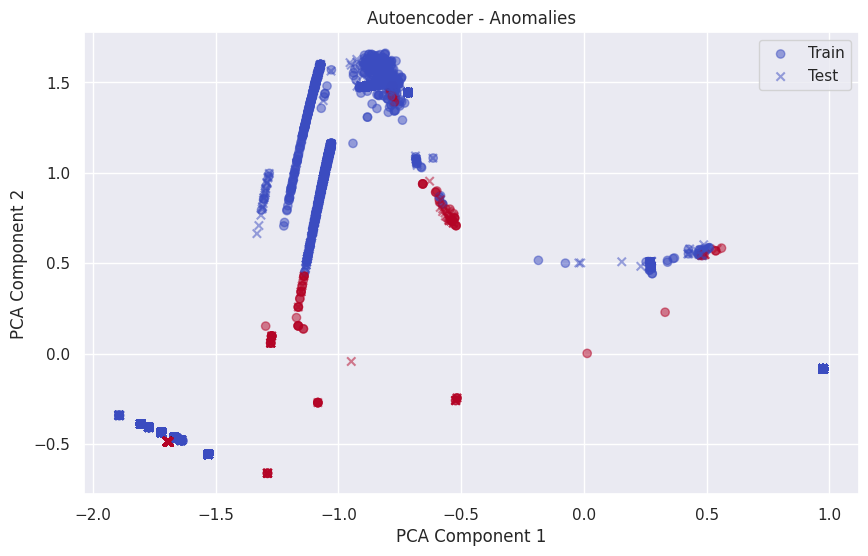

In [82]:
# =========================callbacks = [EarlyStopping(patience=15, restore_best_weights=True)]

history = ae.fit(
    X_tr, X_tr,
    validation_split=0.1,
    epochs=40,
    batch_size=4096,
    shuffle=True,
    verbose=1,
    callbacks=callbacks
)
# ===== VISUALISATION PCA =====
# =========================
pca = PCA(n_components=2)
X_tr_2d = pca.fit_transform(X_tr)
X_te_2d = pca.transform(X_te)

plt.figure(figsize=(10, 6))
plt.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1], c=train_pred, cmap='coolwarm', label='Train', alpha=0.5)
plt.scatter(X_te_2d[:, 0], X_te_2d[:, 1], c=test_pred, cmap='coolwarm', label='Test', alpha=0.5, marker='x')
plt.title("Autoencoder - Anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [83]:
print("\n" + "="*80)
print("📊 COMPARAISON DÉTAILLÉE Train vs Test (DONNÉES BRUTES)")
print("="*80)

# Afficher les différences en % pour toutes les features
print(f"\n{'Feature':<30} {'Train Mean':<15} {'Test Mean':<15} {'Diff %':<12}")
print("-" * 75)

differences_data = []
for feat in ALL_FEATURES:
    train_mean = X_train[feat].mean()
    test_mean = X_test[feat].mean()
    
    if train_mean != 0:
        diff_pct = abs(test_mean - train_mean) / abs(train_mean) * 100
    else:
        diff_pct = 0
    
    differences_data.append((feat, diff_pct, train_mean, test_mean))
    print(f"{feat:<30} {train_mean:<15.4f} {test_mean:<15.4f} {diff_pct:<12.2f}%")

# Trier par différence décroissante
differences_data.sort(key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("🔴 TOP 10 FEATURES AVEC LES PLUS GRANDES DIFFÉRENCES:")
print("="*80)
for feat, diff_pct, train_mean, test_mean in differences_data[:10]:
    print(f"{feat:<30} Diff: {diff_pct:>8.2f}%")



📊 COMPARAISON DÉTAILLÉE Train vs Test (DONNÉES BRUTES)

Feature                        Train Mean      Test Mean       Diff %      
---------------------------------------------------------------------------
bytes                          2166.2594       1004.4582       53.63       %
packets                        31.9467         15.1337         52.63       %
minPacketLength                109.2224        72.9995         33.16       %
maxPacketLength                113.4294        74.7777         34.08       %
meanPacketLength               109.6634        73.0997         33.34       %
stddevPacketLength             0.9911          0.3670          62.97       %
bytesPerSecond                 810.2619        356.9907        55.94       %
packetsPerSecond               11.8117         5.1516          56.39       %
totalBytesUpstream             1392.2286       605.1367        56.53       %
totalBytesDownstream           774.0308        361.8287        53.25       %
totalPacketsUpstream 